# Lab 4: Handwritten Digit Recognition with an MLP (MNIST)

This notebook builds, trains, and evaluates a Multi-Layer Perceptron (MLP) for classifying MNIST handwritten digits (0-9). It covers: data loading, preprocessing, model building, hyperparameter experiments, training/loss plots, a confusion matrix, MSE, misclassified-image analysis, saving/reloading the model, and predicting a brand-new handwritten digit image.

**Note:** Cells that report results (accuracies, times, plots) will only show real numbers once you run the notebook yourself. Sections that need a decision based on your actual results (e.g. picking the best hyperparameter configuration) are marked with `# EDIT:` comments for you to fill in after looking at your output.

## 1. Import Libraries
Import TensorFlow/Keras for building and training the model, NumPy for array work, Matplotlib for plotting, scikit-learn for the train/validation split and confusion matrix, pandas for the experiment results table, and PIL (Pillow) for loading a new custom image later.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from PIL import Image
import time
import gc

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.21.0
Keras version: 3.12.4


## 2. Load the MNIST Dataset
Load the built-in MNIST dataset from Keras. It comes pre-split into a training set (60,000 images) and a test set (10,000 images), each 28x28 grayscale pixels with a digit label 0-9.

In [23]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train_full shape:", x_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)


x_train_full shape: (60000, 28, 28)
y_train_full shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


## 3. Explore the Data
Visualize a handful of sample digits with their labels to confirm the data loaded correctly, and check how many examples exist per class (class balance).

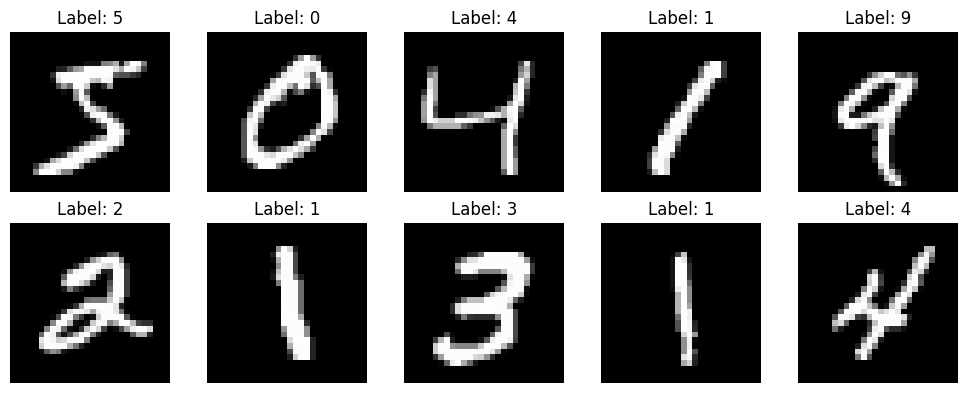

Class distribution (training set):
  Digit 0: 5923 examples
  Digit 1: 6742 examples
  Digit 2: 5958 examples
  Digit 3: 6131 examples
  Digit 4: 5842 examples
  Digit 5: 5421 examples
  Digit 6: 5918 examples
  Digit 7: 6265 examples
  Digit 8: 5851 examples
  Digit 9: 5949 examples


In [24]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_full[i], cmap="gray")
    ax.set_title(f"Label: {y_train_full[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

labels, counts = np.unique(y_train_full, return_counts=True)
print("Class distribution (training set):")
for l, c in zip(labels, counts):
    print(f"  Digit {l}: {c} examples")


## 4. Preprocess the Data
Normalize pixel values from the [0, 255] integer range to the [0.0, 1.0] float range. This keeps the numbers small and consistent, which helps the network train faster and more stably. Images are kept as 28x28 for now — the `Flatten` layer inside the model will turn each image into a 784-length vector (28 * 28 = 784) automatically.

In [25]:
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Pixel value range after normalization:", x_train_full.min(), "to", x_train_full.max())


Pixel value range after normalization: 0.0 to 1.0


## 5. Train / Validation Split
Reserve the official test set only for the final evaluation. Split 10% of the training data into a validation set, which we'll use to monitor overfitting/underfitting and to guide hyperparameter decisions during experimentation.

In [26]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.1,
    random_state=42,
    stratify=y_train_full
)

print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)
print("x_test shape:", x_test.shape)


x_train shape: (54000, 28, 28)
x_val shape: (6000, 28, 28)
x_test shape: (10000, 28, 28)


## 6. Model-Building Function
Define a reusable function that builds and compiles an MLP given a list of hidden-layer sizes and a learning rate. The architecture is:

`Flatten -> Dense(hidden_1, ReLU) -> ... -> Dense(hidden_n, ReLU) -> Dense(10, softmax)`

- **Flatten**: converts each 28x28 image into a flat vector of 784 input features.
- **Dense layer**: every input is connected to every neuron via a learned weight, plus a learned bias; each neuron computes a weighted sum of its inputs.
- **ReLU**: a non-linear activation (`max(0, x)`) applied after each hidden Dense layer, letting the network learn non-linear patterns instead of behaving like a single linear function.
- **Output Dense(10)**: produces 10 raw scores (logits), one per digit class.
- **Softmax**: converts the 10 logits into a probability distribution over the 10 classes that sums to 1.
- **Cross-entropy loss** (`sparse_categorical_crossentropy`): measures how far the predicted probability distribution is from the true label; training uses gradient descent (via the Adam optimizer) to adjust weights/biases to minimize this loss — this is backpropagation in action.

In [27]:
def build_model(hidden_layers=(128, 64), learning_rate=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28)))
    model.add(layers.Flatten())
    for n_units in hidden_layers:
        model.add(layers.Dense(n_units, activation="relu"))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_model(hidden_layers=(128, 64), learning_rate=0.001)
baseline_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Baseline Model
Train the baseline model on the training set, validating on the validation set after every epoch. Record wall-clock training time (required by the assignment) and keep the `history` object, which stores accuracy/loss per epoch for plotting next.

- **Epoch**: one full pass through the entire training set.
- **Batch size**: number of training examples processed before the model's weights are updated once.

In [28]:
BATCH_SIZE = 32
EPOCHS = 15

start_time = time.time()
history = baseline_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)
baseline_training_time = time.time() - start_time

print(f"Baseline training time: {baseline_training_time:.2f} seconds")


Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9283 - loss: 0.2472 - val_accuracy: 0.9518 - val_loss: 0.1549
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9675 - loss: 0.1043 - val_accuracy: 0.9643 - val_loss: 0.1161
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9791 - loss: 0.0692 - val_accuracy: 0.9688 - val_loss: 0.1090
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9851 - loss: 0.0496 - val_accuracy: 0.9655 - val_loss: 0.1239
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9880 - loss: 0.0388 - val_accuracy: 0.9668 - val_loss: 0.1300
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9907 - loss: 0.0293 - val_accuracy: 0.9725 - val_loss: 0.1168
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9914 - loss: 0.0267 - val_accuracy: 0.9747 - val_loss: 0.1098
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9923 - loss: 0.0228 - 

## 8. Baseline Accuracy and Loss Curves
Plot the BASELINE model's training vs. validation accuracy and loss across epochs. This is an exploratory check on the baseline only — the final reported plots use the FINAL model and appear later, in section 14.

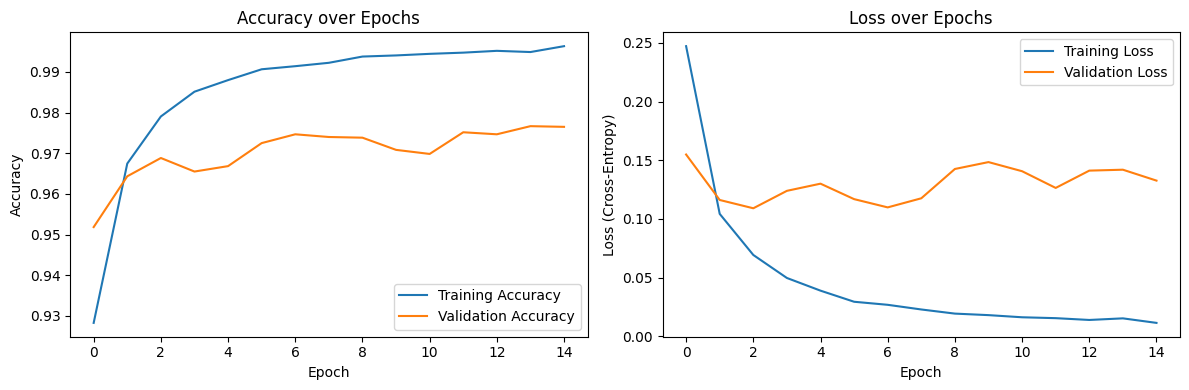

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Training Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Training Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (Cross-Entropy)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Evaluate the Baseline Model on the Test Set
Evaluate the BASELINE model on the test set. This is an exploratory sanity check only — it is not the model's final reported result. The final training/validation/test accuracy and loss (from the FINAL model) are reported in section 15. After these numbers are captured, `baseline_model` is deleted and the Keras session is cleared to free memory before the hyperparameter experiments begin.

In [30]:
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(x_test, y_test, verbose=0)
baseline_train_loss_final = history.history["loss"][-1]
baseline_train_acc_final = history.history["accuracy"][-1]

print(f"Baseline Training Accuracy: {baseline_train_acc_final:.4f}")
print(f"Baseline Training Loss: {baseline_train_loss_final:.4f}")
print(f"Baseline Test Accuracy: {baseline_test_acc:.4f}")
print(f"Baseline Test Loss: {baseline_test_loss:.4f}")

# Free the baseline model now that its metrics have been captured above.
# The upcoming hyperparameter experiments train several models in a row,
# so releasing this one first keeps peak memory usage lower.
del baseline_model
keras.backend.clear_session()
gc.collect()


Baseline Training Accuracy: 0.9964
Baseline Training Loss: 0.0113
Baseline Test Accuracy: 0.9795
Baseline Test Loss: 0.1195


0

## 10. Hyperparameter Experiments (Controlled, One Variable at a Time)
To see each hyperparameter's effect without confounding results, we vary **one hyperparameter at a time** while holding everything else fixed at a shared baseline configuration (architecture = (128, 64), batch size = 32, learning rate = 0.001, epochs = 15). The baseline is trained once and reused as the reference point in every sweep below, so we don't retrain it repeatedly.

Four small, targeted sweeps are run:
- **Architecture** — vary the hidden-layer sizes, everything else fixed at baseline
- **Batch Size** — vary the batch size, everything else fixed at baseline
- **Learning Rate** — vary the learning rate, everything else fixed at baseline
- **Epochs** — vary the number of epochs, everything else fixed at baseline

Only training and validation performance are used for comparison here — the test set stays untouched until the final model is chosen (section 15).

Each experiment also releases its model (`keras.backend.clear_session()` + `gc.collect()`) right after its metrics are recorded, so memory doesn't build up across the ten training runs — useful on a machine with limited RAM. Only one model exists in memory at a time; nothing is trained simultaneously.

In [31]:
BASELINE_CONFIG = {"hidden_layers": (128, 64), "batch_size": 32, "learning_rate": 0.001, "epochs": 15}

def run_experiment(name, sweep, hidden_layers, batch_size, learning_rate, epochs):
    model = build_model(hidden_layers=hidden_layers, learning_rate=learning_rate)
    start = time.time()
    hist = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        batch_size=batch_size,
        epochs=epochs,
        verbose=0
    )
    elapsed = time.time() - start
    result = {
        "Experiment": name,
        "Sweep": sweep,
        "Architecture": f"{len(hidden_layers)} layer(s)",
        "Neurons": hidden_layers,
        "Batch Size": batch_size,
        "Learning Rate": learning_rate,
        "Epochs": epochs,
        "Training Accuracy": hist.history["accuracy"][-1],
        "Validation Accuracy": hist.history["val_accuracy"][-1],
        "Training Time (s)": elapsed
    }

    # Free this experiment's model before starting the next one, so memory
    # doesn't accumulate across the sweep (helpful on machines with limited RAM).
    del model
    keras.backend.clear_session()
    gc.collect()

    return result

results = []

# Baseline (trained once, reused as the reference row in every sweep below)
print("Running Baseline ...")
results.append(run_experiment("Baseline", "Baseline", **BASELINE_CONFIG))
print(f"  -> train_acc={results[-1]['Training Accuracy']:.4f}, "
      f"val_acc={results[-1]['Validation Accuracy']:.4f}, "
      f"time={results[-1]['Training Time (s)']:.1f}s")

# --- Sweep 1: Architecture (hidden layers/neurons), everything else fixed ---
for name, hidden_layers in [("Arch_smaller", (64,)), ("Arch_wider", (256, 128))]:
    print(f"Running {name} ...")
    cfg = dict(BASELINE_CONFIG, hidden_layers=hidden_layers)
    results.append(run_experiment(name, "Architecture", **cfg))
    print(f"  -> train_acc={results[-1]['Training Accuracy']:.4f}, "
          f"val_acc={results[-1]['Validation Accuracy']:.4f}, "
          f"time={results[-1]['Training Time (s)']:.1f}s")

# --- Sweep 2: Batch Size, everything else fixed ---
for name, batch_size in [("Batch_64", 64), ("Batch_128", 128)]:
    print(f"Running {name} ...")
    cfg = dict(BASELINE_CONFIG, batch_size=batch_size)
    results.append(run_experiment(name, "Batch Size", **cfg))
    print(f"  -> train_acc={results[-1]['Training Accuracy']:.4f}, "
          f"val_acc={results[-1]['Validation Accuracy']:.4f}, "
          f"time={results[-1]['Training Time (s)']:.1f}s")

# --- Sweep 3: Learning Rate, everything else fixed ---
for name, learning_rate in [("LR_high_0.01", 0.01), ("LR_low_0.0005", 0.0005)]:
    print(f"Running {name} ...")
    cfg = dict(BASELINE_CONFIG, learning_rate=learning_rate)
    results.append(run_experiment(name, "Learning Rate", **cfg))
    print(f"  -> train_acc={results[-1]['Training Accuracy']:.4f}, "
          f"val_acc={results[-1]['Validation Accuracy']:.4f}, "
          f"time={results[-1]['Training Time (s)']:.1f}s")

# --- Sweep 4: Epochs, everything else fixed ---
for name, epochs in [("Epochs_5", 5), ("Epochs_10", 10), ("Epochs_20", 20)]:
    print(f"Running {name} ...")
    cfg = dict(BASELINE_CONFIG, epochs=epochs)
    results.append(run_experiment(name, "Epochs", **cfg))
    print(f"  -> train_acc={results[-1]['Training Accuracy']:.4f}, "
          f"val_acc={results[-1]['Validation Accuracy']:.4f}, "
          f"time={results[-1]['Training Time (s)']:.1f}s")

results_df = pd.DataFrame(results)
results_df


Running Baseline ...
  -> train_acc=0.9952, val_acc=0.9770, time=65.5s
Running Arch_smaller ...
  -> train_acc=0.9969, val_acc=0.9703, time=50.0s
Running Arch_wider ...
  -> train_acc=0.9957, val_acc=0.9785, time=103.9s
Running Batch_64 ...
  -> train_acc=0.9966, val_acc=0.9760, time=38.0s
Running Batch_128 ...
  -> train_acc=0.9967, val_acc=0.9757, time=20.0s
Running LR_high_0.01 ...
  -> train_acc=0.9775, val_acc=0.9603, time=63.8s
Running LR_low_0.0005 ...
  -> train_acc=0.9973, val_acc=0.9767, time=61.4s
Running Epochs_5 ...
  -> train_acc=0.9877, val_acc=0.9700, time=21.1s
Running Epochs_10 ...
  -> train_acc=0.9940, val_acc=0.9747, time=41.2s
Running Epochs_20 ...
  -> train_acc=0.9968, val_acc=0.9752, time=81.1s


,Experiment,Sweep,Architecture,Neurons,Batch Size,Learning Rate,Epochs,Training Accuracy,Validation Accuracy,Training Time (s)
0,Baseline,Baseline,2 layer(s),"(128, 64)",32,0.0010,15,0.995241,0.977000,65.526470
1,Arch_smaller,Architecture,1 layer(s),"(64,)",32,0.0010,15,0.996926,0.970333,50.026713
2,Arch_wider,Architecture,2 layer(s),"(256, 128)",32,0.0010,15,0.995741,0.978500,103.854286
3,Batch_64,Batch Size,2 layer(s),"(128, 64)",64,0.0010,15,0.996556,0.976000,37.963714
4,Batch_128,Batch Size,2 layer(s),"(128, 64)",128,0.0010,15,0.996685,0.975667,19.994135
5,LR_high_0.01,Learning Rate,2 layer(s),"(128, 64)",32,0.0100,15,0.977537,0.960333,63.826795
6,LR_low_0.0005,Learning Rate,2 layer(s),"(128, 64)",32,0.0005,15,0.997333,0.976667,61.418066
7,Epochs_5,Epochs,2 layer(s),"(128, 64)",32,0.0010,5,0.987667,0.970000,21.096597
8,Epochs_10,Epochs,2 layer(s),"(128, 64)",32,0.0010,10,0.994000,0.974667,41.231524
9,Epochs_20,Epochs,2 layer(s),"(128, 64)",32,0.0010,20,0.996759,0.975167,81.078269


## 11. Training Accuracy vs. Training Time
Plot each experiment's final training accuracy against how long it took to train, to see whether the more accurate configurations are also the more expensive ones to train.

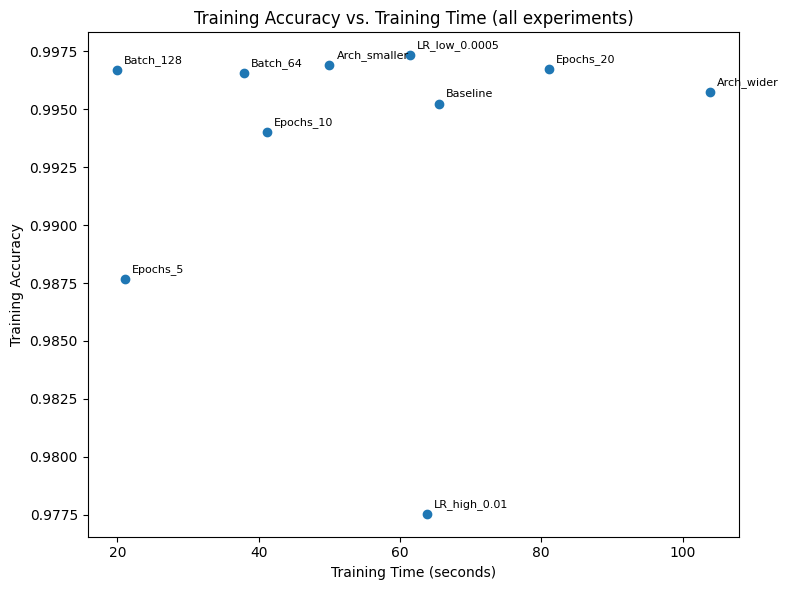

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(results_df["Training Time (s)"], results_df["Training Accuracy"])
for _, row in results_df.iterrows():
    plt.annotate(row["Experiment"], (row["Training Time (s)"], row["Training Accuracy"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.xlabel("Training Time (seconds)")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs. Training Time (all experiments)")
plt.tight_layout()
plt.show()


## 12. Compare Experiments and Select the Final Configuration
Since each sweep changes only one hyperparameter, we can look at each sweep on its own (with the shared baseline row as reference) to read off that hyperparameter's effect. We also check the train/validation accuracy gap: a large gap suggests **overfitting**; both accuracies being low suggests **underfitting**.

In [33]:
results_df["Train-Val Gap"] = results_df["Training Accuracy"] - results_df["Validation Accuracy"]

cols = ["Experiment", "Neurons", "Batch Size", "Learning Rate", "Epochs",
        "Training Accuracy", "Validation Accuracy", "Train-Val Gap", "Training Time (s)"]

for sweep_name in ["Architecture", "Batch Size", "Learning Rate", "Epochs"]:
    print(f"--- {sweep_name} sweep (baseline included for reference) ---")
    subset = results_df[(results_df["Sweep"] == sweep_name) | (results_df["Sweep"] == "Baseline")]
    display(subset[cols])


--- Architecture sweep (baseline included for reference) ---


,Experiment,Neurons,Batch Size,Learning Rate,Epochs,Training Accuracy,Validation Accuracy,Train-Val Gap,Training Time (s)
0,Baseline,"(128, 64)",32,0.001,15,0.995241,0.977000,0.018241,65.526470
1,Arch_smaller,"(64,)",32,0.001,15,0.996926,0.970333,0.026593,50.026713
2,Arch_wider,"(256, 128)",32,0.001,15,0.995741,0.978500,0.017241,103.854286


--- Batch Size sweep (baseline included for reference) ---


,Experiment,Neurons,Batch Size,Learning Rate,Epochs,Training Accuracy,Validation Accuracy,Train-Val Gap,Training Time (s)
0,Baseline,"(128, 64)",32,0.001,15,0.995241,0.977000,0.018241,65.526470
3,Batch_64,"(128, 64)",64,0.001,15,0.996556,0.976000,0.020556,37.963714
4,Batch_128,"(128, 64)",128,0.001,15,0.996685,0.975667,0.021019,19.994135


--- Learning Rate sweep (baseline included for reference) ---


,Experiment,Neurons,Batch Size,Learning Rate,Epochs,Training Accuracy,Validation Accuracy,Train-Val Gap,Training Time (s)
0,Baseline,"(128, 64)",32,0.0010,15,0.995241,0.977000,0.018241,65.526470
5,LR_high_0.01,"(128, 64)",32,0.0100,15,0.977537,0.960333,0.017204,63.826795
6,LR_low_0.0005,"(128, 64)",32,0.0005,15,0.997333,0.976667,0.020667,61.418066


--- Epochs sweep (baseline included for reference) ---


,Experiment,Neurons,Batch Size,Learning Rate,Epochs,Training Accuracy,Validation Accuracy,Train-Val Gap,Training Time (s)
0,Baseline,"(128, 64)",32,0.001,15,0.995241,0.977000,0.018241,65.526470
7,Epochs_5,"(128, 64)",32,0.001,5,0.987667,0.970000,0.017667,21.096597
8,Epochs_10,"(128, 64)",32,0.001,10,0.994000,0.974667,0.019333,41.231524
9,Epochs_20,"(128, 64)",32,0.001,20,0.996759,0.975167,0.021593,81.078269


**EDIT — fill this in after viewing your actual results tables above. Do not invent values:**

- Architecture: best value found = `___`, effect observed = `___`
- Batch Size: best value found = `___`, effect observed = `___`
- Learning Rate: best value found = `___`, effect observed = `___`
- Epochs: best value found = `___`, effect observed = `___`
- Any sign of overfitting (large train-val gap) in a particular sweep: `___`
- Any sign of underfitting (both accuracies low) in a particular sweep: `___`
- Final configuration chosen by combining the best value from each sweep: `___`
- Why this combination was chosen: `___`

## 13. Train the Final Model
Using the best value found for each hyperparameter above, build and train the final model. Update the `FINAL_*` variables below to match your chosen configuration, then run this cell. (This cell only trains the model — plots and evaluation are in the next two sections.)

In [ ]:
# EDIT: set these to the best value found for each hyperparameter in section 12
FINAL_HIDDEN_LAYERS = (256,128)
FINAL_BATCH_SIZE = 32
FINAL_LEARNING_RATE = 0.001
FINAL_EPOCHS = 15

final_model = build_model(hidden_layers=FINAL_HIDDEN_LAYERS, learning_rate=FINAL_LEARNING_RATE)

start_time = time.time()
final_history = final_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=FINAL_BATCH_SIZE,
    epochs=FINAL_EPOCHS,
    verbose=1
)
final_training_time = time.time() - start_time

print(f"Final model training time: {final_training_time:.2f} seconds")


## 14. Final Accuracy and Loss Curves
Plot the FINAL model's training vs. validation accuracy and loss across epochs — this replaces the baseline plots in section 8 as the reported curves, since the FINAL model is what gets saved and evaluated.

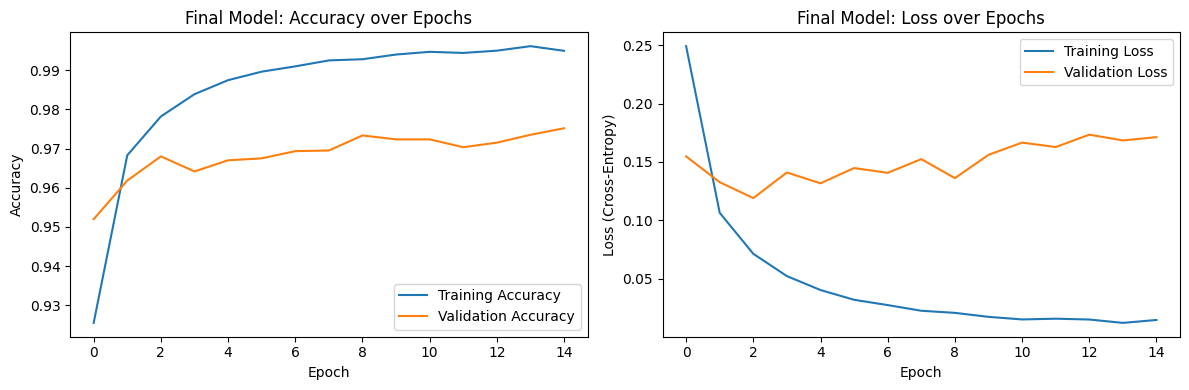

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(final_history.history["accuracy"], label="Training Accuracy")
axes[0].plot(final_history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Final Model: Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(final_history.history["loss"], label="Training Loss")
axes[1].plot(final_history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Final Model: Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (Cross-Entropy)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 15. Final Evaluation (Training, Validation, Test)
Evaluate the FINAL model on the test set, and report training/validation/test accuracy and loss together. **These are the numbers that belong in the lab report — not the baseline's from section 9.**

In [35]:
final_train_acc = final_history.history["accuracy"][-1]
final_train_loss = final_history.history["loss"][-1]
final_val_acc = final_history.history["val_accuracy"][-1]
final_val_loss = final_history.history["val_loss"][-1]

final_test_loss, final_test_acc = final_model.evaluate(x_test, y_test, verbose=0)

print(f"Final Training Accuracy:   {final_train_acc:.4f}")
print(f"Final Training Loss:       {final_train_loss:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Validation Loss:     {final_val_loss:.4f}")
print(f"Final Test Accuracy:       {final_test_acc:.4f}")
print(f"Final Test Loss:           {final_test_loss:.4f}")


Final Training Accuracy:   0.9949
Final Training Loss:       0.0146
Final Validation Accuracy: 0.9752
Final Validation Loss:     0.1712
Final Test Accuracy:       0.9758
Final Test Loss:           0.1311


## 16. Confusion Matrix (Final Model)
Generate predictions with the FINAL model on the test set and build a 10x10 confusion matrix, where entry (i, j) counts how many digit-`i` images were predicted as digit `j`. The diagonal shows correct predictions; off-diagonal entries reveal which digits the final model tends to confuse.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


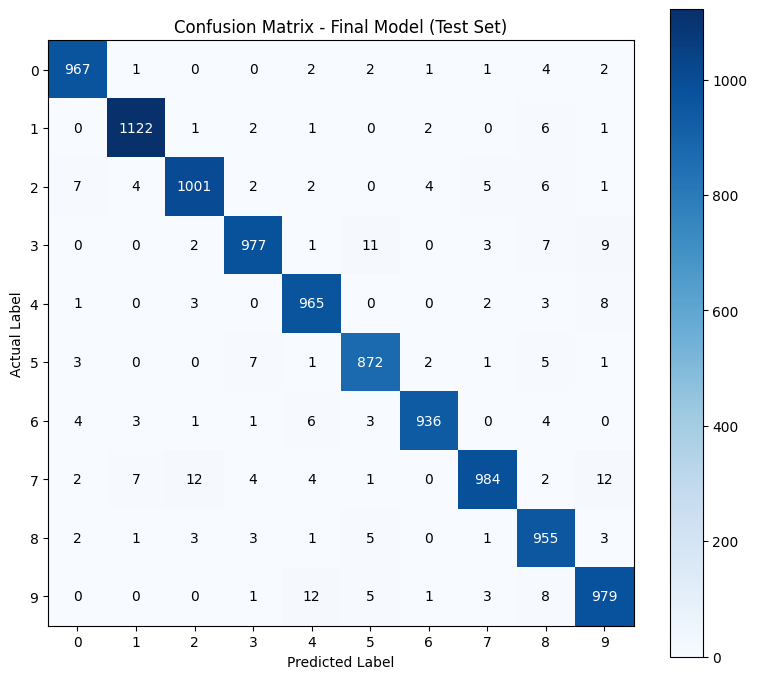

In [36]:
final_y_pred_probs = final_model.predict(x_test)
final_y_pred = np.argmax(final_y_pred_probs, axis=1)

cm = confusion_matrix(y_test, final_y_pred)

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Final Model (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar()
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()


## 17. Mean Squared Error (MSE)
Cross-entropy is the loss the FINAL model was actually trained with (see the concept note in section 18). MSE is reported here only as an additional metric, comparing the one-hot encoded true labels to the FINAL model's predicted probability vectors.

In [37]:
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)
mse = np.mean((y_test_onehot - final_y_pred_probs) ** 2)
print(f"Mean Squared Error (final model, test set): {mse:.6f}")


Mean Squared Error (final model, test set): 0.004116


## 18. Cross-Entropy Loss (Concept Note)
Cross-entropy loss measures the difference between the true label distribution (a one-hot vector, e.g. `[0,0,0,1,0,0,0,0,0,0]` for digit 3) and the predicted probability distribution from softmax. For a single example it is:

`Loss = -sum( y_true_i * log(y_pred_i) )` for i = 0..9

Since `y_true` is 0 everywhere except the correct class, this simplifies to `-log(predicted probability of the correct class)`. The loss is small when the model assigns high probability to the correct class, and grows sharply as that probability approaches 0. For a classification problem with 10 mutually exclusive classes like MNIST, (sparse) categorical cross-entropy is the appropriate training loss — this is exactly what `final_model` was compiled and trained with, and `Final Test Loss` in section 15 is this quantity, averaged over the test set.

## 19. Misclassified Image Analysis (Final Model)
Find test images the FINAL model got wrong, then display several of them with their actual label, predicted label, and a brief note on a likely reason for the mistake (e.g. ambiguous handwriting, digits that look visually similar, unusual stroke style) — based only on what's visible in each image.

Number of misclassified test images (final model): 242 out of 10000


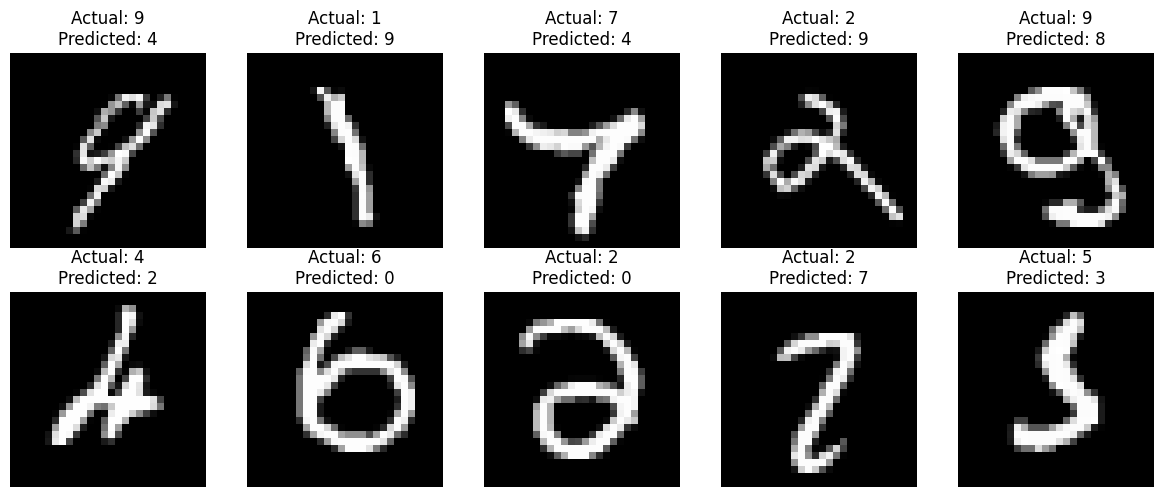

In [38]:
misclassified_idx = np.where(final_y_pred != y_test)[0]
print(f"Number of misclassified test images (final model): {len(misclassified_idx)} out of {len(y_test)}")

n_show = 10
show_idx = misclassified_idx[:n_show]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, show_idx):
    ax.imshow(x_test[idx], cmap="gray")
    ax.set_title(f"Actual: {y_test[idx]}\nPredicted: {final_y_pred[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# EDIT: after viewing the images above, write a short note for each one
# (or a general pattern) explaining why you think the model confused it,
# e.g. "messy/ambiguous strokes", "digit shape close to another class",
# "unusually written digit", etc. Base this on what you actually see.


## 20. Save the Final Model
Save the FINAL trained model to disk in the native Keras format (`.keras`) so it can be reloaded later without retraining.

In [39]:
MODEL_FILENAME = "mnist_mlp_final.keras"
final_model.save(MODEL_FILENAME)
print(f"Model saved as: {MODEL_FILENAME}")


Model saved as: mnist_mlp_final.keras


## 21. Reload the Final Model and Verify
Load the saved model back from disk into a new variable and re-evaluate it on the test set. Matching the FINAL model's test accuracy/loss from section 15 confirms the save/reload worked correctly.

In [40]:
reloaded_model = keras.models.load_model(MODEL_FILENAME)

reload_test_loss, reload_test_acc = reloaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Reloaded model - Test Accuracy: {reload_test_acc:.4f}")
print(f"Reloaded model - Test Loss: {reload_test_loss:.4f}")


Reloaded model - Test Accuracy: 0.9758
Reloaded model - Test Loss: 0.1311


## 22. Sample Predictions from the Reloaded Model
Show several test images with their actual label and the label predicted by the RELOADED model, making clear these predictions come from the reloaded model, not the in-memory `final_model`.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


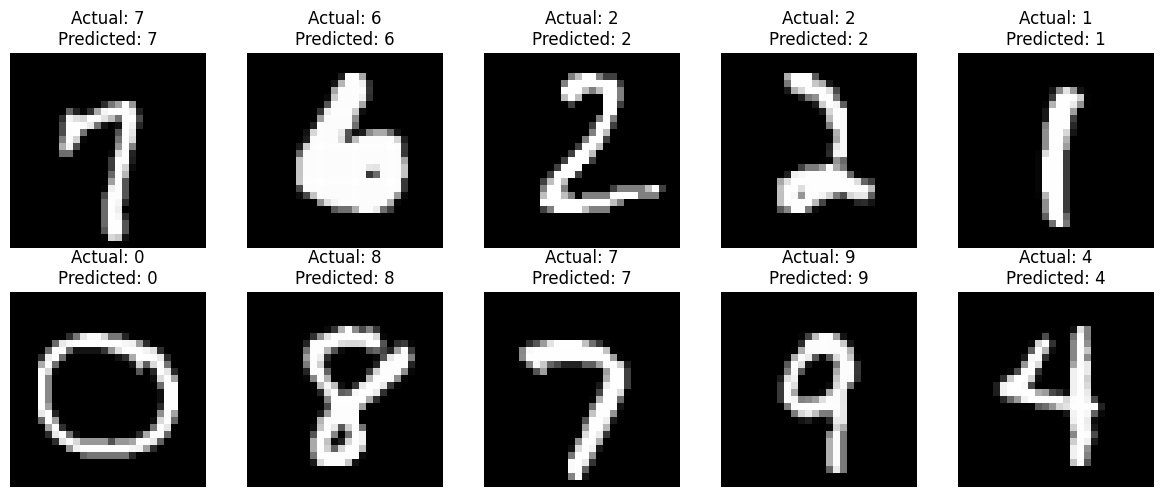

In [41]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(x_test), size=10, replace=False)

sample_preds = np.argmax(reloaded_model.predict(x_test[sample_idx]), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx, pred in zip(axes.flat, sample_idx, sample_preds):
    ax.imshow(x_test[idx], cmap="gray")
    ax.set_title(f"Actual: {y_test[idx]}\nPredicted: {pred}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 23. Predict on a New Handwritten Digit Image
Demonstrate the model working on a brand-new image that was never part of MNIST — for example, a photo or scan of a digit you wrote yourself. Before the model can use it, the image must be preprocessed to match what the model expects:

- **Grayscale conversion**: MNIST images have a single color channel, so a color photo must be converted to grayscale.
- **Resize to 28x28**: the model's input layer expects exactly 28x28 pixels.
- **Color/contrast matching**: MNIST digits are white strokes on a black background — a photo of pencil-on-paper is usually the opposite (dark strokes on a light background) and needs its colors inverted to match.
- **Normalization**: pixel values must be scaled to [0, 1], the same way the training data was scaled.
- **Correct input shape**: the model expects a batch dimension, so a single image of shape `(28, 28)` must be reshaped to `(1, 28, 28)`.

Place your own digit image file (e.g. `my_digit.png`) in the same folder as this notebook, update `IMAGE_PATH` below, and run the cell. Predictions use the RELOADED model, showing it works independently of the original training session.

/tmp/ipykernel_3199/272509368.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img_array = np.array(img).astype("float32")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


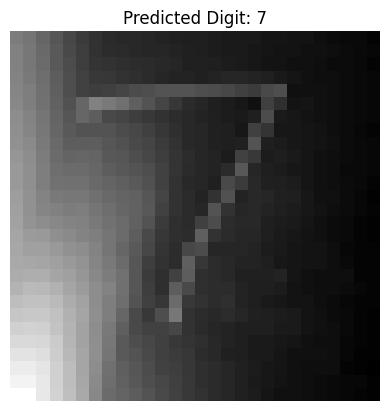

Predicted digit: 7
Predicted probabilities: [2.0094092e-05 3.6485081e-12 6.2876487e-10 8.1235485e-06 3.2988513e-08
 1.9307110e-07 2.1108670e-02 9.7873515e-01 1.3469469e-10 1.2761289e-04]


In [44]:
IMAGE_PATH = "my_digit.png"  # EDIT: path to your own handwritten digit image

def preprocess_new_image(path, invert=True):
    img = Image.open(path).convert("L")          # grayscale conversion
    img = img.resize((28, 28))                    # resize to 28x28
    img_array = np.array(img).astype("float32")
    if invert:
        img_array = 255.0 - img_array              # match MNIST's white-on-black style
    img_array = img_array / 255.0                  # normalization
    img_array = img_array.reshape(1, 28, 28)        # correct input shape (bat=ch of 1)
    return img_array

try:
    new_image = preprocess_new_image(IMAGE_PATH)
    prediction = reloaded_model.predict(new_image)
    predicted_digit = np.argmax(prediction)

    plt.imshow(new_image[0], cmap="gray")
    plt.title(f"Predicted Digit: {predicted_digit}")
    plt.axis("off")
    plt.show()

    print(f"Predicted digit: {predicted_digit}")
    print(f"Predicted probabilities: {prediction[0]}")
except FileNotFoundError:
    print(f"Image not found at '{IMAGE_PATH}'. "
          f"Add your own digit image to this notebook's folder and update IMAGE_PATH.")


## 24. Final Results Summary
**EDIT — fill in every field below using the actual values produced by this notebook. Do not invent numbers.**

1. **Final architecture:** `Flatten -> Dense(___, ReLU) -> ... -> Dense(10, Softmax)` (from `FINAL_HIDDEN_LAYERS`, section 13)
2. **Hyperparameters:** batch size = `___`, learning rate = `___`, epochs = `___` (section 13)
3. **Final Training Accuracy:** `___` (section 15)
4. **Final Validation Accuracy:** `___` (section 15)
5. **Final Test Accuracy:** `___` (section 15)
6. **Final Training Loss:** `___` (section 15)
7. **Final Validation Loss:** `___` (section 15)
8. **Final Test Loss:** `___` (section 15)
9. **Training time (final model):** `___` seconds (section 13)
10. **Confusion matrix observations:** which digit pairs the final model confuses most, and why (sections 16 & 19)
11. **MSE (final model):** `___` (section 17)
12. **Misclassified-image analysis:** summary of patterns noticed (section 19)
13. **Saved model filename:** `mnist_mlp_final.keras` (section 20)
14. **Reload verification:** reloaded test accuracy = `___`, matches final model = yes/no (section 21)
15. **New handwritten image prediction:** image used, predicted digit, correct or not (section 23)
16. **Hyperparameter effects observed:** brief summary of each sweep's effect (section 12)

## 25. Requirement Checklist

| Requirement | Section(s) | Status |
|---|---|---|
| MLP model (Dense layers only, no CNN) | 6, 7, 13 | Implemented |
| Hyperparameter experiments: layers, neurons, batch size, learning rate, epochs | 10 | Implemented — run to populate results |
| Observe/report effect of each hyperparameter | 12 (EDIT notes) | Implemented — needs your written observations |
| Test accuracy >= 97% | 15 | Implemented — verify after running |
| Avoid under/overfitting, justify generalization | 12 (train-val gap), 14 (curves) | Implemented |
| Training/test accuracy & loss reported | 15, 24 | Implemented |
| Training/test accuracy & loss plots | 14 | Implemented (final model, not baseline) |
| 10x10 confusion matrix | 16 | Implemented (final model) |
| MSE / squared error | 17 | Implemented (final model) |
| Cross-entropy loss used and explained | 6 (used), 18 (explained) | Implemented |
| Training time recorded | 7, 10, 13 | Implemented |
| Training accuracy vs. training time | 11 | Implemented |
| Misclassified-image analysis (~5-10 images, actual vs predicted, reasons) | 19 | Implemented (final model) |
| Save trained model in reusable format | 20 | Implemented (`mnist_mlp_final.keras`) |
| Reload model and verify it works | 21 | Implemented |
| Reloaded model: sample test images with actual/predicted labels | 22 | Implemented |
| Independent prediction on a brand-new handwritten image | 23 | Implemented — needs your own image file |
| Preprocessing explained (grayscale, resize, normalize, shape) | 23 | Implemented |
| All final metrics/plots/confusion matrix/misclassified images use the FINAL model, not baseline | 13-19 | Implemented |
| Controlled, one-variable-at-a-time hyperparameter experiments | 10 | Implemented |
| Test set reserved for final evaluation only (not used for tuning) | 10-12 (no test access), 15 (test used only here) | Implemented |
| Beginner-friendly code, MLP only, no unnecessary libraries | Throughout | Implemented |
